In [ ]:
!pip install -q pyomo

In [ ]:
# https://jckantor.github.io/ND-Pyomo-Cookbook/notebooks/01.02-Running-Pyomo-on-Google-Colab.html#installing-pyomo-and-solvers
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_plot(params, res, ncol=3, regime_bounds = []):
    alpha_list = np.array(res["alpha"])
    n = len(res["D"][0])   # number of customers

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    lw = 2

    # ---------------------------------------------------------
    # 1. Profit, total utility, NSW
    # ---------------------------------------------------------
    profit_list = np.array(res["profit"])
    U_total_list = np.array([np.sum(U) for U in res["U"]])

    # NSW = sum log U_i (we assume you computed it separately or we recompute)
    NSW_list, SW_list = [], []
    for i in range(len(res["U"])):
        U = res["U"][i]
        Pi = res["profit"][i]
        if np.all(U > 0):
            NSW_list.append(np.sum(np.log(U)))
        else:
            NSW_list.append(-np.inf)
        SW_list.append(np.sum(U) + Pi)
    NSW_list = np.array(NSW_list)
    SW_list = np.array(SW_list)

    axs[0].plot(alpha_list, profit_list, 'r', label=r'$\Pi$', linewidth=lw)
    axs[0].plot(alpha_list, NSW_list, color='purple', label=r'$W_{CNW}$', linewidth=lw)
    axs[0].plot(alpha_list, U_total_list, 'g', label='U', linewidth=lw)
    axs[0].plot(alpha_list, SW_list, color='blue', label=r'$W_{SW}$', linewidth=lw)


    # ---------------------------------------------------------
    # 2. Prices p_i
    # ---------------------------------------------------------
    p_mat = np.array(res["p"])   # shape (len(alpha), n)

    colors = ['tab:orange', 'tab:blue', 'tab:green']#plt.cm.tab20(np.linspace(0, 1, n))
    for i in range(n):
        axs[1].plot(alpha_list, p_mat[:, i], label=fr'$p_{i+1}$', linewidth=lw, color=colors[i])


    # ---------------------------------------------------------
    # 3. Demands D_i with dashed Dbar_i
    # ---------------------------------------------------------
    D_mat = np.array(res["D"])   # shape (len(alpha), n)
    Dbar = np.array(params["Dbar"])

    for i in range(n):
        axs[2].plot(alpha_list, D_mat[:, i], label=fr'$D_{i+1}$', linewidth=lw, color=colors[i])
        axs[2].axhline(Dbar[i], ls='--', linewidth=1.5, color=colors[i])


    # ---------------------------------------------------------
    # 4. Utilities U_i
    # ---------------------------------------------------------
    U_mat = np.array(res["U"])

    for i in range(n):
        axs[3].plot(alpha_list, U_mat[:, i], label=fr'$U_{i+1}$', linewidth=lw, color=colors[i])


    # ---------------------------------------------------------
    # Formatting for all panels
    # ---------------------------------------------------------
    for i in range(4):
        axs[i].set_xlim(0, 1)
        axs[i].legend(
            loc='lower center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=ncol if i != 0 else 2,
            fontsize=18,
            frameon=True
        )
        axs[i].set_xlabel(r'$\alpha$', fontsize=24)

    if len(regime_bounds) > 0:
      for i in range(4):
        for bound in regime_bounds:
          axs[i].axvline(bound, color='gray', linestyle='--', linewidth=1.5)

    plt.tight_layout()
    plt.show()


In [ ]:
import pyomo.environ as pyo
import numpy as np

def solve_baseline(params):
    a = params["a"]
    b = params["b"]
    pi = params["pi"]
    Dbar = np.array(params["Dbar"], dtype=float)
    Ds = params["Ds"]
    n = len(Dbar)

    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, n-1)

    # variables (0 ≤ D_i ≤ Dbar_i)
    m.D = pyo.Var(m.I, bounds=lambda m,i: (0, float(Dbar[i])))

    # price
    def price(m, i):
        return a * m.D[i] + (b - a * Dbar[i])

    # objective: profit
    def obj_rule(m):
        return pi * sum(m.D[i] for i in m.I) \
                - sum(price(m,i) * m.D[i] for i in m.I)
    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    # capacity
    m.cap = pyo.Constraint(expr=sum(m.D[i] for i in m.I) <= Ds)

    # solve
    solver = pyo.SolverFactory("ipopt")
    solver.solve(m, tee=False)

    # extract solution
    D = np.array([pyo.value(m.D[i]) for i in m.I])
    p = a*D + (b - a*Dbar)
    U = 0.5*a*D**2
    profit = pyo.value(m.obj)

    return dict(D=D, p=p, U=U, profit=profit)

In [ ]:
params = dict(
    a = 1.0,
    b = 9.0,
    pi = 12,
    Dbar = [1,8],
    Ds = 10
)

In [ ]:
sol0 = solve_baseline(params)  # ignore fairness
D0 = sol0["D"]
Dbar = np.array(params["Dbar"], dtype=float)

# demand fairness baseline Δ
delta_p = max(
    abs(params["a"] * D0[i] + (params["b"]-params["a"]*Dbar[i]) \
                - params["a"] * D0[j] + (params["b"]-params["a"]*Dbar[j]))
    for i in range(len(Dbar)) for j in range(i+1, len(Dbar))
)

In [ ]:
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition
import numpy as np
from itertools import product


##############################################
# Solve the model for one alpha and one index
##############################################

def demand_from_price(idx, p, a, b, Dbar):
    if idx == 0:
        return 0
    elif idx == 2:
        return Dbar
    else:
        return (p-b)/a + Dbar

def solve_one_alpha(params, alpha, delta_x, index, Dbar_arr, solver):
    """
    Solve the optimization problem for a single (alpha, index) pair.

    If the model is infeasible or the solver fails, this function returns:
        D = None, p = None, U = None, profit = -1
    """

    # Unpack parameters
    a = params["a"]
    b = params["b"]
    pi = params["pi"]
    Ds = params["Ds"]
    n = len(Dbar_arr)

    # Safety check: index must have one type per customer
    if len(index) != n:
        raise ValueError(f"len(index) = {len(index)} but n = {n}. "
                         "index must specify a type for each customer.")

    # Create a Pyomo model
    m = pyo.ConcreteModel()

    # Index set for customers
    m.I = pyo.RangeSet(0, n - 1)

    # Decision variables
    # p[i]: price, here also bounded in [0, Dbar[i]] (you can change this if needed)
    m.p = pyo.Var(m.I, bounds=lambda m, i: (0.0, None))

    # Constraint list (we will only use m.c.add(...))
    m.c = pyo.ConstraintList()

    # Type-specific constraints for the given indices
    # index is something like [0, 1] or [1, 2], etc.
    D_list = []
    for i in range(len(index)):
        idx = int(index[i])
        if idx == 0:
            m.c.add(m.p[i] <= b - a * Dbar_arr[i])
            D_list.append(0 * m.p[i])
        elif idx == 1:
            m.c.add(m.p[i] <= b)
            m.c.add(m.p[i] >= b - a * Dbar_arr[i])
            D_list.append((m.p[i]-b)/a + Dbar_arr[i])
        else:
            m.c.add(m.p[i] >= b)
            D_list.append(0 * m.p[i] + Dbar_arr[i])


    # Capacity constraint: total demand cannot exceed Ds
    m.c.add(sum(D_list) <= Ds)

    # Fairness bound: |p_i − p_j| ≤ (1 − alpha) * delta_x
    bound = (1.0 - float(alpha)) * float(delta_x)

    # Add pairwise fairness constraints using only m.c.add(...)
    for i in m.I:
        for j in m.I:
            if i < j:
                # p_i - p_j <= bound
                m.c.add(m.p[i] - m.p[j] <= bound)
                # -(p_i - p_j) <= bound  <=>  p_j - p_i <= bound
                m.c.add(-(m.p[i] - m.p[j]) <= bound)

     # Objective: maximize profit
    def obj_rule(m):
        return sum(
            (pi - m.p[i]) * ((m.p[i] - b)/a + Dbar_arr[i]) if int(index[i]) == 1
              else (pi - m.p[i]) * Dbar_arr[i] if int(index[i]) == 2
              else 0.0                                     # idx == 0
              for i in m.I)


    m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    # ---- Solve the model ----
    try:
        results = solver.solve(m, tee=False)#, load_solutions=False)
    except ValueError:
        # Solver failed hard (e.g., "Cannot load a SolverResults object ...")
        return dict(D=None, p=None, U=None, profit=-1)

    status = results.solver.status
    term = results.solver.termination_condition

    # If not solved to optimal/feasible, treat as infeasible
    if (status != SolverStatus.ok) or (
        term not in [
            TerminationCondition.optimal,
            TerminationCondition.locallyOptimal,
            TerminationCondition.feasible,
        ]
    ):
        return dict(D=None, p=None, U=None, profit=-1)

    # Extract solutions into numpy arrays
    p = np.array([pyo.value(m.p[i]) for i in m.I], dtype=float)
    D = np.array([demand_from_price(index[i], p[i], a, b, Dbar_arr[i]) for i in range(len(p))])
    # Compute utilities:
    # U_i = D_i * p_i − 1/2 * a * D_i^2 − (b − a * Dbar_i) * D_i
    U = D * p - 0.5 * a * D**2 - (b - a * Dbar_arr) * D

    # Get objective (profit) value
    profit = pyo.value(m.obj)

    return dict(D=D, p=p, U=U, profit=profit)


##############################################
# Simulation over many alphas and index sets
##############################################
def simulation(params, alphas, delta_x, index_candidates):
    """
    For each alpha, solve the model for all index candidates,
    and keep only the solution that yields the maximum profit.

    If all candidates are infeasible for a given alpha,
    that alpha will have:
        index = None, D = None, p = None, U = None, profit = -1
    """

    # Precompute Dbar as a numpy array (to avoid repeated conversion)
    Dbar_arr = np.array(params["Dbar"], dtype=float)

    # Create the solver only once (faster than recreating every time)
    solver = pyo.SolverFactory("ipopt")

    # Dictionary to store results
    res = {"alpha": [], "index": [], "D": [], "p": [], "U": [], "profit": []}

    # Loop over alpha values
    for alpha in alphas:
        best_sol = None
        best_index = None

        # Try all index combinations for this alpha
        for idx in index_candidates:
            sol = solve_one_alpha(params, alpha, delta_x, idx, Dbar_arr, solver)

            # skip infeasible ones (profit == -1)
            if sol["profit"] < 0:
                continue

            if (best_sol is None) or (sol["profit"] > best_sol["profit"]):
                best_sol = sol
                best_index = idx

        # If no feasible solution was found for this alpha
        if best_sol is None:
            res["alpha"].append(alpha)
            res["index"].append(None)
            res["D"].append(None)
            res["p"].append(None)
            res["U"].append(None)
            res["profit"].append(-1)
        else:
            res["alpha"].append(alpha)
            res["index"].append(best_index)
            res["D"].append(best_sol["D"])
            res["p"].append(best_sol["p"])
            res["U"].append(best_sol["U"])
            res["profit"].append(best_sol["profit"])

    return res


## N=2

In [ ]:
import logging
logging.getLogger('pyomo').setLevel(logging.ERROR)

params = dict(
a = 1.0,
b = 9.0,
pi = 12,
Dbar = [1,8],
Ds = 8
)

sol0 = solve_baseline(params)  # ignore fairness
D0 = sol0["D"]
Dbar = np.array(params["Dbar"], dtype=float)

# demand fairness baseline Δ
delta_p = max(
    abs(params["a"] * D0[i] + (params["b"]-params["a"]*Dbar[i]) \
                - params["a"] * D0[j] - (params["b"]-params["a"]*Dbar[j]))
    for i in range(len(Dbar)) for j in range(i+1, len(Dbar))
)

alphas = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.73, 0.731, 0.732, 0.8, 0.9, 1.0]

# All index combinations [i, j] with i, j in {0, 1, 2}
index_candidates = [list(idx) for idx in product(range(3), repeat=2)]
# index_candidates = [[1,1]]

result = simulation(params, alphas, delta_p, index_candidates)
print(result)

{'alpha': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.73, 0.731, 0.732, 0.8, 0.9, 1.0], 'index': [[1, 1], [1, 1], [2, 1], [2, 1], [2, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [0, 1], [0, 1], [0, 1], [0, 1]], 'D': [array([1.00000009, 5.50005952]), array([1.00000009, 5.75000007]), array([1.        , 5.99999989]), array([1.        , 6.24999989]), array([1.       , 6.4999999]), array([0.875     , 6.62499999]), array([0.75      , 6.74999999]), array([0.625     , 6.87499999]), array([0.5875    , 6.91249999]), array([0.58625   , 6.91374999]), array([0. , 5.5]), array([0. , 5.5]), array([0. , 5.5]), array([0. , 5.5])], 'p': [array([9.00000009, 6.50005952]), array([9.00000009, 6.75000007]), array([8.99999991, 6.99999989]), array([8.99999991, 7.24999989]), array([8.99999991, 7.4999999 ]), array([8.875     , 7.62499999]), array([8.75      , 7.74999999]), array([8.625     , 7.87499999]), array([8.5875    , 7.91249999]), array([8.58625   , 7.91374999]), array([6.1048047, 6.5      ]), array([6.24911

In [ ]:
for i in range(1,5):
  result['p'][-i][0] = 6.5

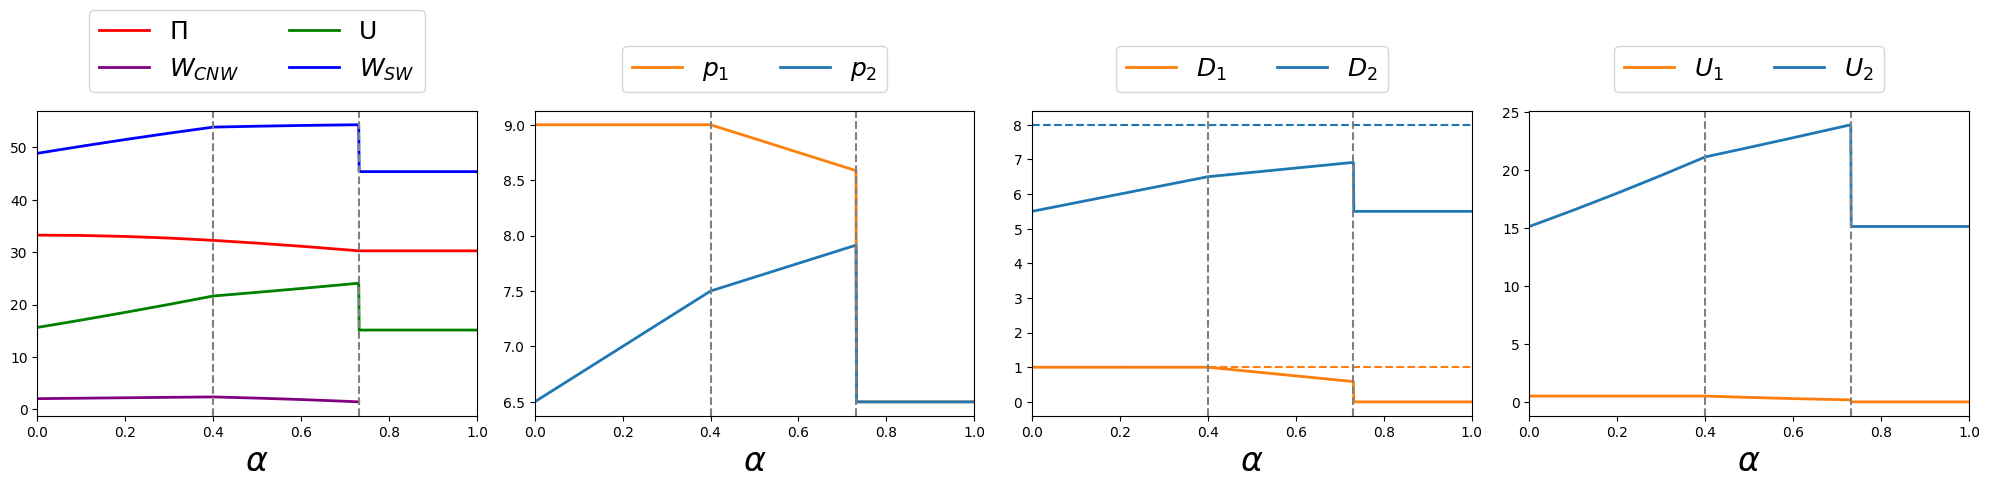

In [ ]:
draw_plot(params, result, regime_bounds=[0.4, 0.731])

## N=3

In [ ]:
params = dict(
a = 1.0,
b = 9.0,
pi = 12,
Dbar = [1,5,8],
Ds = 10
)

sol0 = solve_baseline(params)  # ignore fairness
D0 = sol0["D"]
Dbar = np.array(params["Dbar"], dtype=float)

# demand fairness baseline Δ
delta_p = max(
    abs(params["a"] * D0[i] + (params["b"]-params["a"]*Dbar[i]) \
                - params["a"] * D0[j] - (params["b"]-params["a"]*Dbar[j]))
    for i in range(len(Dbar)) for j in range(i+1, len(Dbar))
)

alphas = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.68,0.6825,0.685,0.7,0.8,0.9,1]

# All index combinations [i, j] with i, j in {0, 1, 2}
index_candidates = [list(idx) for idx in product(range(3), repeat=3)]
# index_candidates = [[1,1]]

result = simulation(params, alphas, delta_p, index_candidates)
print(result)

{'alpha': [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.68, 0.6825, 0.685, 0.7, 0.8, 0.9, 1], 'index': [[1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [1, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1], [0, 1, 1]], 'D': [array([1.00000009, 3.74996711, 5.25003303]), array([0.98750006, 3.50000009, 5.51250008]), array([0.85000007, 3.50000008, 5.65000008]), array([0.71250007, 3.50000008, 5.78750008]), array([0.57500007, 3.50000008, 5.92500008]), array([0.43750007, 3.50000008, 6.06250008]), array([0.30000007, 3.50000008, 6.20000008]), array([0.19000007, 3.50000008, 6.31000008]), array([0.        , 3.68656249, 5.8134375 ]), array([0.        , 3.68312499, 5.816875  ]), array([0.        , 3.66249999, 5.8375    ]), array([0.   , 3.525, 5.975]), array([0.        , 3.3875    , 6.11249999]), array([0.        , 3.25      , 6.24999999])], 'p': [array([9.00000009, 7.74996711, 6.25003303]), array([8.98750006, 7.50000009, 6.51250008]), array([8.85000007, 7.50000008, 6.

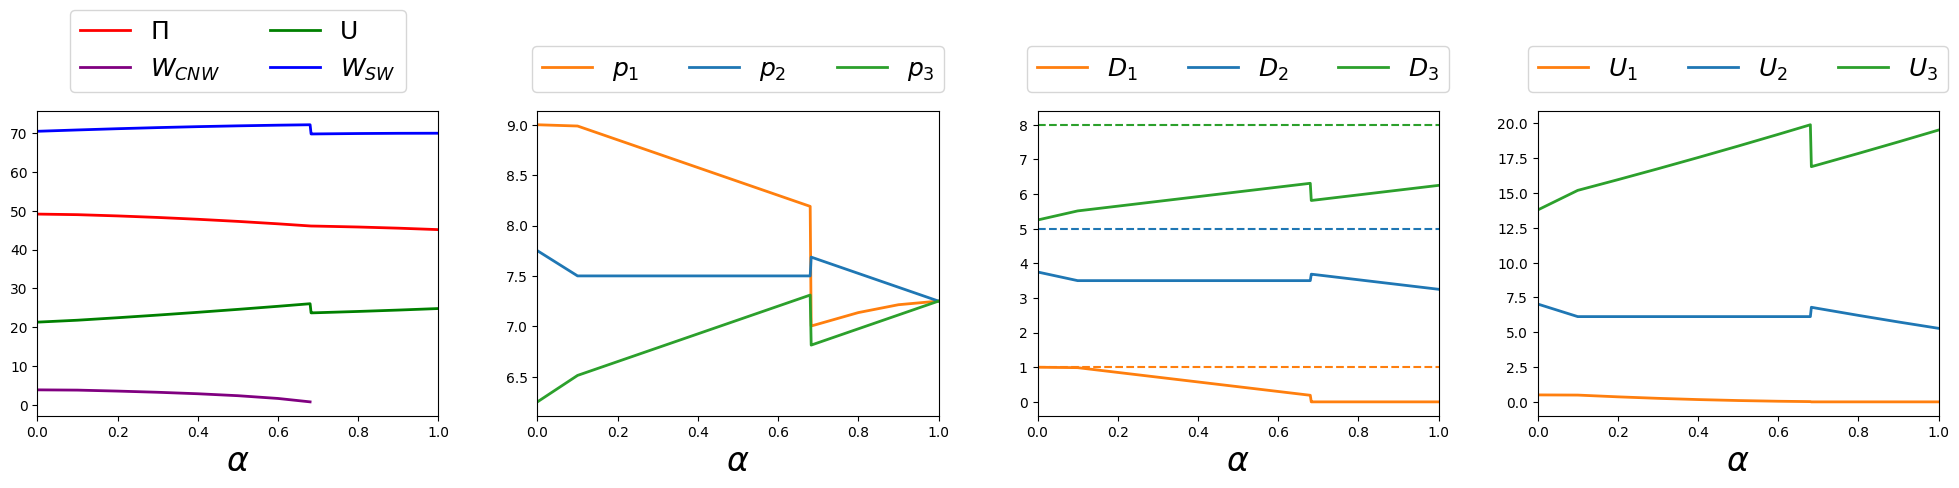

In [ ]:
draw_plot(params, result)